<a href="https://colab.research.google.com/github/ThiagoBrandaorj/Deep_learning/blob/main/C%C3%B3pia_de_05a_Imagens_com_RNAs_e_CNNs_(AC1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TAREFA 05a - AC1**

Nesta primeira tarefa que vale parte da nota AC, vamos trabalhar alguns cenários onde utilizaremos RNAs MLP e CNNs LeNet-5 para resolver problemas que envolvem imagens.

## **1) Classificação binária (cães vs. gatos em baixa resolução)**

### **O problema**

O objetivo é construir e treinar uma RNA MLP e uma CNN LeNet-5 para classificar uma imagem como contendo um `gato` ou um `cachorro`. Deve ser apresentada a comparação de resultados e uma justificativa baseada nos dados e resultados para a escolha de uma das abordagens.

### **O Conjunto de Dados**

Utilizaremos o dataset **"Cats vs. Dogs"**, disponível através do `tensorflow_datasets`.




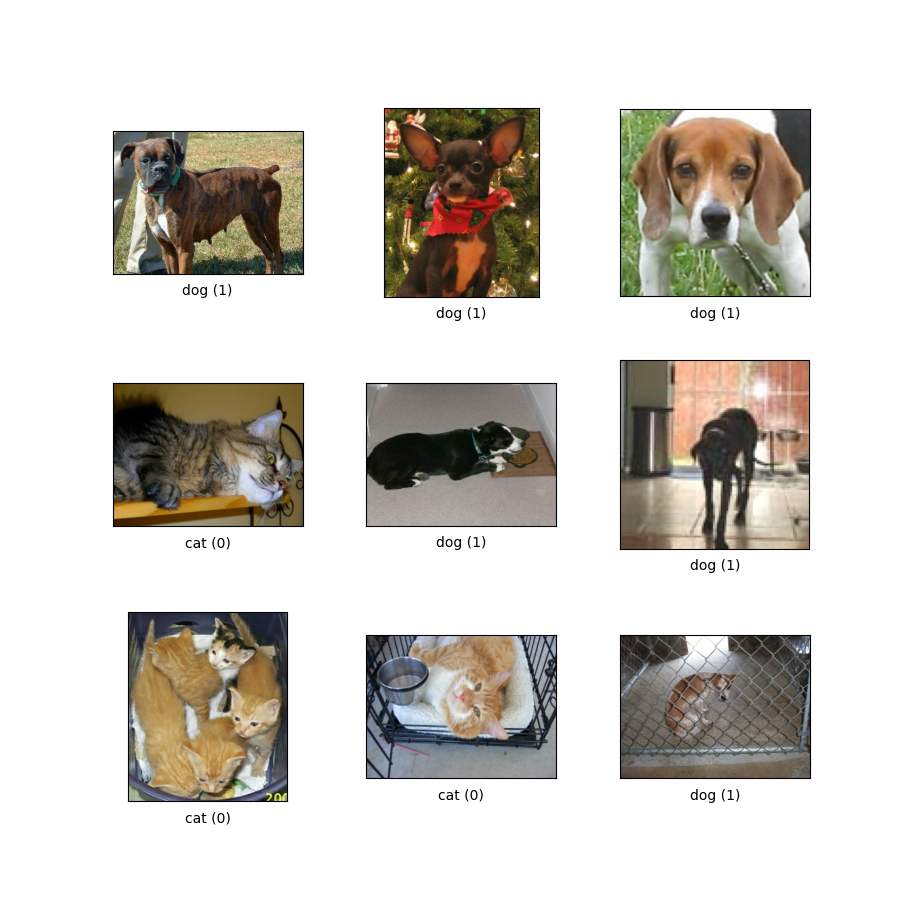

# 1 - EDA

**Primeiro iremos obter o conjunto de dados**

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')

import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

dataset = tfds.load(name="cats_vs_dogs")
print(f"Available keys: {dataset.keys()}")
data = dataset["train"]

Available keys: dict_keys(['train'])


**Verificando as classes de cada imagem e seus percentuais no conjunto de dados**

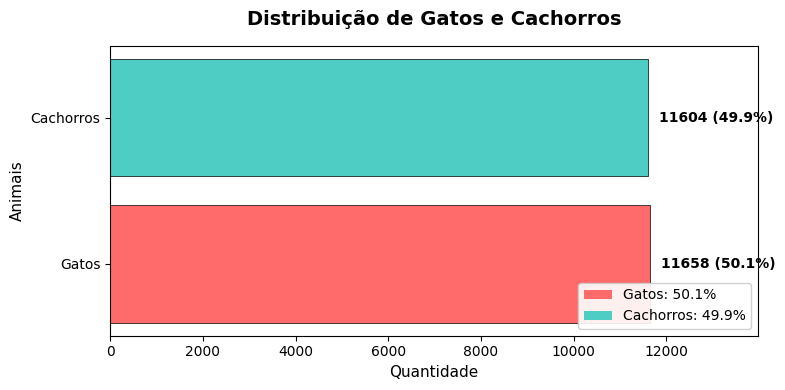

In [ ]:
cats = 0
dogs = 0
for image in data:
    if image['label'].numpy() == 0:
        cats += 1
    else:
        dogs += 1

total = cats + dogs
percent_cats = (cats / total) * 100
percent_dogs = (dogs / total) * 100
cat = ['Gatos', 'Cachorros']
val = [cats, dogs]
colors = ['#FF6B6B', '#4ECDC4']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(cat, val, color=colors, edgecolor='black', linewidth=0.5)
for i, (bar, valor, percent) in enumerate(zip(bars, val, [percent_cats, percent_dogs])):
    ax.text(valor + (total * 0.01), bar.get_y() + bar.get_height()/2,
            f'{int(valor)} ({percent:.1f}%)',
            va='center', ha='left', fontsize=10, fontweight='bold')

ax.set_title('Distribuição de Gatos e Cachorros', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Quantidade', fontsize=11)
ax.set_ylabel('Animais', fontsize=11)
legend_elements = [plt.Rectangle((0,0),1,1, facecolor=colors[0], label=f'Gatos: {percent_cats:.1f}%'),
                   plt.Rectangle((0,0),1,1, facecolor=colors[1], label=f'Cachorros: {percent_dogs:.1f}%')]

ax.legend(handles=legend_elements, loc='lower right', framealpha=0.9)
ax.set_xlim(0, max(val) + (total * 0.1))
plt.tight_layout()
plt.show()

**Podemos verificar pelo gráfico que estamos diante de um conjunto de dados balanceado, portanto posteriormente quando estivermos nos concentrando em avaliar as métricas dos modelos iremos olhar para a acurácia**

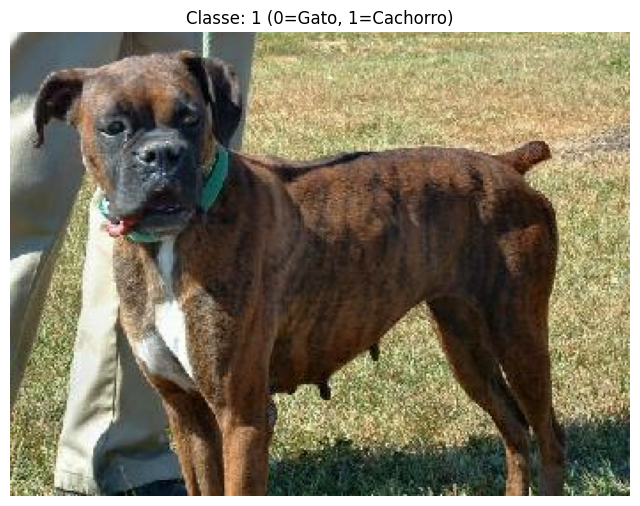

Shape da imagem: (262, 350, 3)


In [ ]:
for example in data.take(1):
    imagem = example['image'].numpy()
    label = example['label'].numpy()
    plt.figure(figsize=(8, 8))
    plt.imshow(imagem)
    plt.title(f"Classe: {label} (0=Gato, 1=Cachorro)")
    plt.axis('off')
    plt.show()
    print(f"Shape da imagem: {imagem.shape}")

**Podemos perceber que as imagens estão em RGB(3 canais), a seguir iremos dividir os dados em treino, teste e validação.**

In [ ]:
with tf.device('/CPU:0'):
    total_dataset_size = tf.data.experimental.cardinality(data).numpy()
    train_size = int(0.7 * total_dataset_size)
    test_size = int(0.15 * total_dataset_size)
    valid_size = int(0.15 * total_dataset_size)
    print(f"Total: {total_dataset_size}")
    print(f"Treino: {train_size}, Validação: {valid_size}, Teste: {test_size}")

    data = data.shuffle(10_000, seed=42)
    train_set = data.take(train_size)
    remaining = data.skip(train_size)
    val_set = remaining.take(valid_size)
    test_set = remaining.skip(valid_size)

    print(f"\nTamanhos após divisão:")
    print(f"Treino: {tf.data.experimental.cardinality(train_set).numpy()}")
    print(f"Validação: {tf.data.experimental.cardinality(val_set).numpy()}")
    print(f"Teste: {tf.data.experimental.cardinality(test_set).numpy()}")

Total: 23262
Treino: 16283, Validação: 3489, Teste: 3489

Tamanhos após divisão:
Treino: 16283
Validação: 3489
Teste: 3490


**Dividimos o conjunto de dados seguindo a divisão: 70% treino, 15% validação e 15% para teste, além do mais embaralhamos o conjunto de dados antes da divisão, usando um buffer_size de 10.000, ou seja, embaralhando de 10 mil em 10 mil imagens, quanto maior o buffer_size melhor a aleatoriedade da divisão[1].**

**A seguir iremos verificar se a divisão preservou a distribuição original das classes, é claro que não precisa ser o mesmo percentual, visto que é alatório porém deve-se preservar mais ou menos o que é o conjunto de dados original**

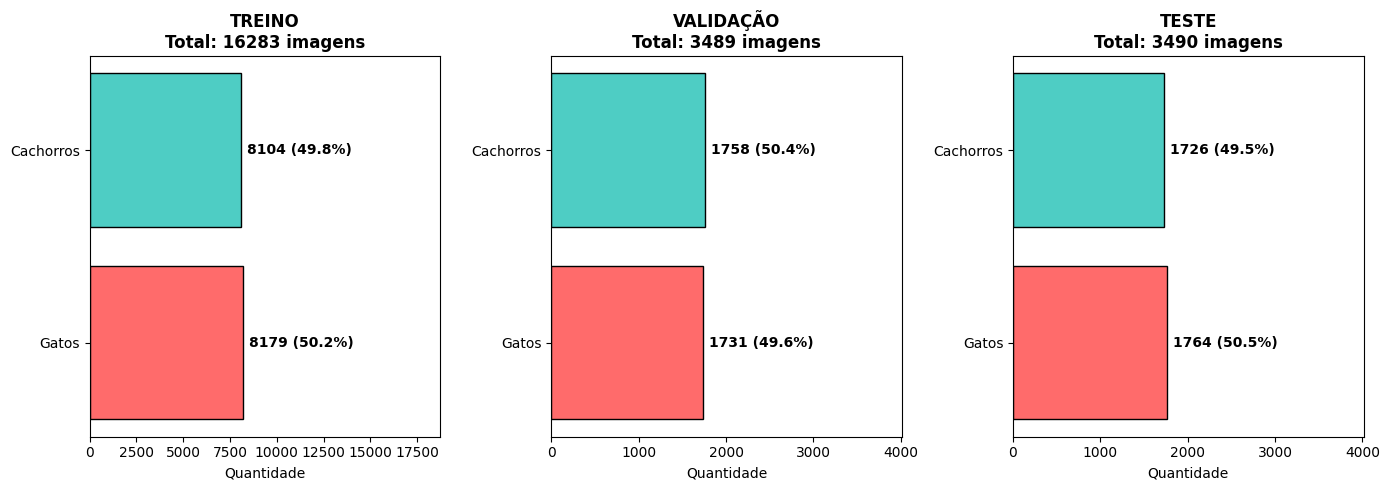

In [ ]:
# Função adaptada para dicionário
def contar_labels_dict(dataset):
    cats = dogs = 0
    for exemplo in dataset:
        label = exemplo['label'].numpy()  # Acessa a label no dicionário
        if label == 0:
            cats += 1
        else:
            dogs += 1
    return cats, dogs

# Contar em cada conjunto
train_cats, train_dogs = contar_labels_dict(train_set)
val_cats, val_dogs = contar_labels_dict(val_set)
test_cats, test_dogs = contar_labels_dict(test_set)

# Calcular percentuais
train_total = train_cats + train_dogs
val_total = val_cats + val_dogs
test_total = test_cats + test_dogs

train_cats_pct = (train_cats / train_total) * 100
train_dogs_pct = (train_dogs / train_total) * 100
val_cats_pct = (val_cats / val_total) * 100
val_dogs_pct = (val_dogs / val_total) * 100
test_cats_pct = (test_cats / test_total) * 100
test_dogs_pct = (test_dogs / test_total) * 100

# CRIAR 3 GRÁFICOS SEPARADOS
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Gráfico 1 - Treino
bars1 = axes[0].barh(['Gatos', 'Cachorros'], [train_cats, train_dogs],
                     color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[0].set_title(f'TREINO\nTotal: {train_total} imagens', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Quantidade', fontsize=10)

# Adicionar valores e percentuais no Treino
for i, (valor, pct) in enumerate(zip([train_cats, train_dogs], [train_cats_pct, train_dogs_pct])):
    axes[0].text(valor + (train_total * 0.02), i,
                 f'{valor} ({pct:.1f}%)',
                 va='center', ha='left', fontweight='bold', fontsize=10)

# Gráfico 2 - Validação
bars2 = axes[1].barh(['Gatos', 'Cachorros'], [val_cats, val_dogs],
                     color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[1].set_title(f'VALIDAÇÃO\nTotal: {val_total} imagens', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Quantidade', fontsize=10)

# Adicionar valores e percentuais na Validação
for i, (valor, pct) in enumerate(zip([val_cats, val_dogs], [val_cats_pct, val_dogs_pct])):
    axes[1].text(valor + (val_total * 0.02), i,
                 f'{valor} ({pct:.1f}%)',
                 va='center', ha='left', fontweight='bold', fontsize=10)

# Gráfico 3 - Teste
bars3 = axes[2].barh(['Gatos', 'Cachorros'], [test_cats, test_dogs],
                     color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[2].set_title(f'TESTE\nTotal: {test_total} imagens', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Quantidade', fontsize=10)

# Adicionar valores e percentuais no Teste
for i, (valor, pct) in enumerate(zip([test_cats, test_dogs], [test_cats_pct, test_dogs_pct])):
    axes[2].text(valor + (test_total * 0.02), i,
                 f'{valor} ({pct:.1f}%)',
                 va='center', ha='left', fontweight='bold', fontsize=10)

# Ajustar limites dos eixos para acomodar os textos
axes[0].set_xlim(0, train_total + (train_total * 0.15))
axes[1].set_xlim(0, val_total + (val_total * 0.15))
axes[2].set_xlim(0, test_total + (test_total * 0.15))

plt.tight_layout()
plt.show()

**Agora que temos os dados já divididos e preservando a distribuição original das duas classes nos 3 subconjuntos iremos olhar melhor as dimensões das imagens de treino, para encontrar as imagens de maior e menor dimensão, para posteriormente nos modelos definirmos qual o tamanho para as imagens de entrada**

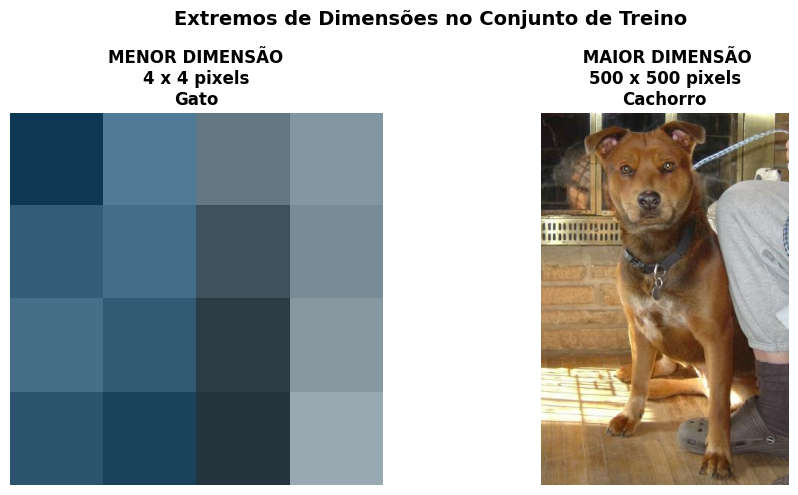

In [ ]:
def encontrar_dimensoes_extremas(dataset, num_amostras=None):
    menor_altura = float('inf')
    menor_largura = float('inf')
    maior_altura = 0
    maior_largura = 0
    imagem_menor = None
    imagem_maior = None
    label_menor = None
    label_maior = None
    total = 0

    for exemplo in dataset:
        imagem = exemplo['image']
        label = exemplo['label']
        altura = imagem.shape[0]
        largura = imagem.shape[1]
        if altura < menor_altura:
            menor_altura = altura
            imagem_menor = imagem
            label_menor = label.numpy()
        if largura < menor_largura:
            menor_largura = largura
        if altura > maior_altura:
            maior_altura = altura
            imagem_maior = imagem
            label_maior = label.numpy()
        if largura > maior_largura:
            maior_largura = largura
        total += 1
        if num_amostras and total >= num_amostras:
            break
    return {
        'menor': {'altura': menor_altura, 'largura': menor_largura,
                  'imagem': imagem_menor, 'label': label_menor},
        'maior': {'altura': maior_altura, 'largura': maior_largura,
                  'imagem': imagem_maior, 'label': label_maior},
        'total_analisado': total
    }

resultados = encontrar_dimensoes_extremas(train_set)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

if resultados['menor']['imagem'] is not None:
    axes[0].imshow(resultados['menor']['imagem'])
    axes[0].set_title(f"MENOR DIMENSÃO\n{resultados['menor']['altura']} x {resultados['menor']['largura']} pixels\n"
                      f"{'Gato' if resultados['menor']['label'] == 0 else 'Cachorro'}",
                      fontweight='bold')
    axes[0].axis('off')
if resultados['maior']['imagem'] is not None:
    axes[1].imshow(resultados['maior']['imagem'])
    axes[1].set_title(f" MAIOR DIMENSÃO\n{resultados['maior']['altura']} x {resultados['maior']['largura']} pixels\n"
                      f"{'Gato' if resultados['maior']['label'] == 0 else 'Cachorro'}",
                      fontweight='bold')
    axes[1].axis('off')
plt.suptitle("Extremos de Dimensões no Conjunto de Treino", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Procurando no treino, conseguimos visualizar que a maior imagem tem dimensão 500x500 enquanto que a menor que tem 4x4 teoricamente seria para representar um gato, porém como podemos ver é impossível identificar qualquer coisa, a imagem é muito pequena para representar um gato, ou seja imagens assim podem atrapalhar o modelo. Dessa forma iremos desconsiderar imagens muito pequenas e excluir elas dos 3 subconjuntos dos dados.**


📊 ESTATÍSTICAS DAS DIMENSÕES
Total de imagens analisadas: 16283

📏 ALTURA:
   Mediana: 375.0 pixels
   Mínimo: 4 pixels
   Máximo: 500 pixels
   Desvio padrão: 96.2

📐 LARGURA:
   Mediana: 467.0 pixels
   Mínimo: 4 pixels
   Máximo: 500 pixels
   Desvio padrão: 108.1

📊 PROPORÇÃO (Altura/Largura):
   Mediana: 0.78


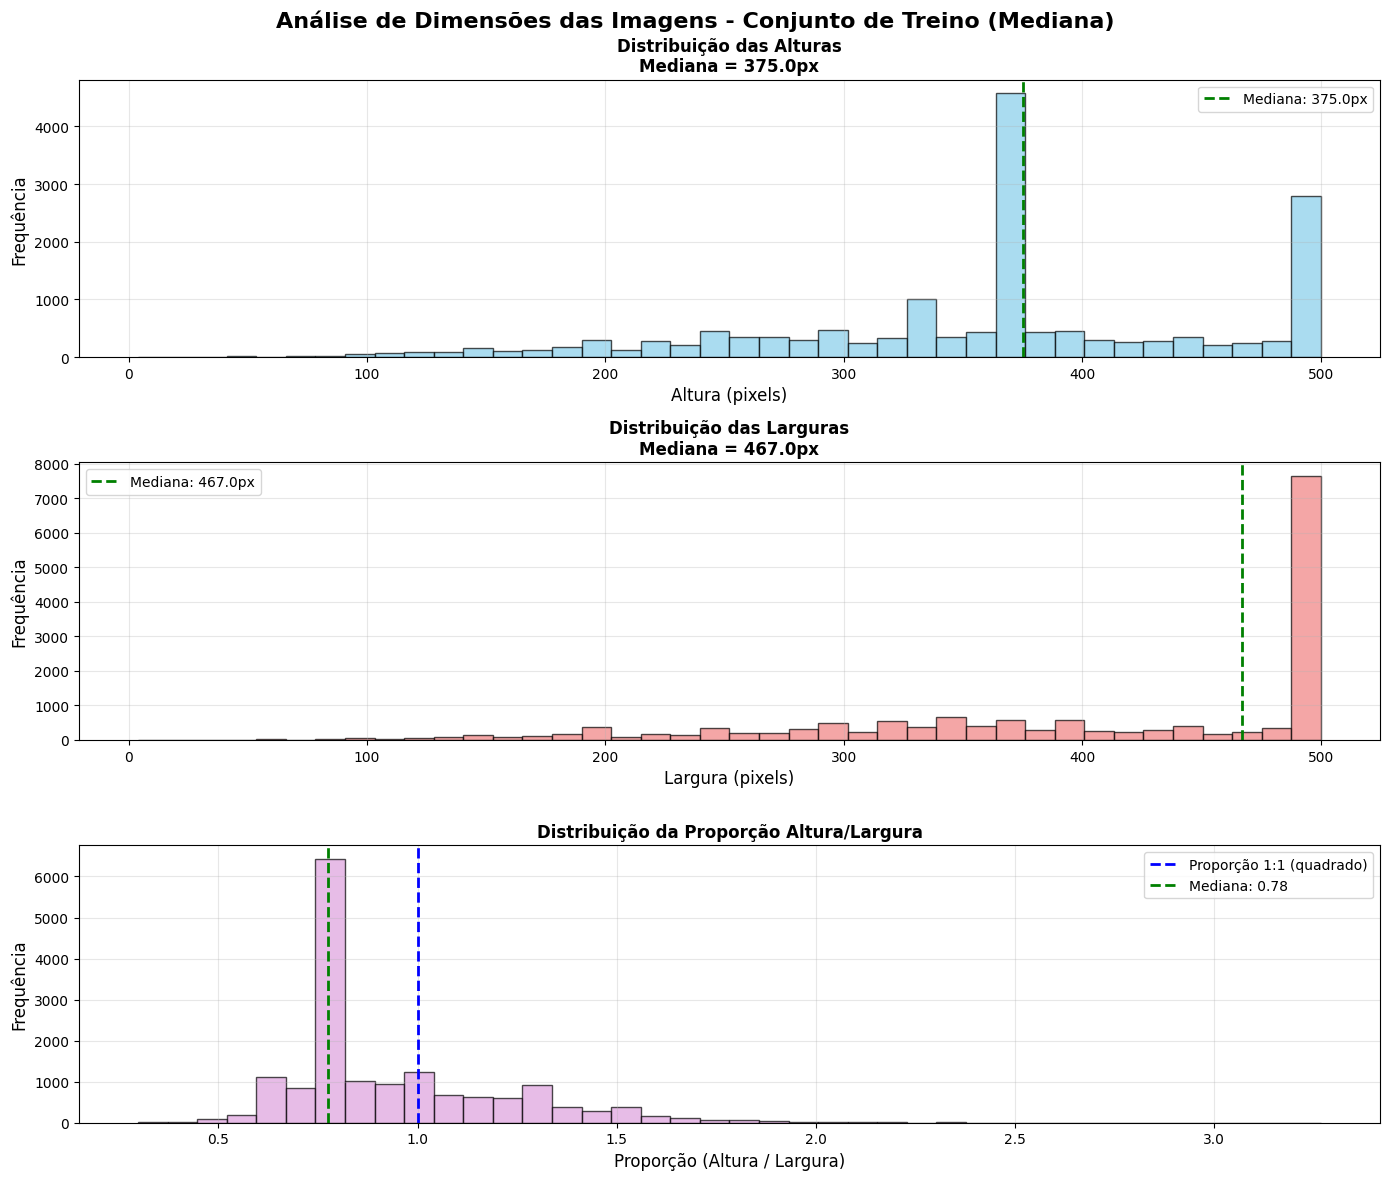

In [ ]:
def coletar_dimensoes(dataset, max_amostras=None):
    alturas = []
    larguras = []
    areas = []
    proporcoes = []

    count = 0
    for exemplo in dataset:
        imagem = exemplo['image']
        h, w = imagem.shape[0], imagem.shape[1]

        alturas.append(h)
        larguras.append(w)
        areas.append(h * w)
        proporcoes.append(h / w)

        count += 1
        if max_amostras and count >= max_amostras:
            break

    return {
        'alturas': np.array(alturas),
        'larguras': np.array(larguras),
        'proporcoes': np.array(proporcoes)
    }
dimensoes = coletar_dimensoes(train_set)
altura_mediana = np.median(dimensoes['alturas'])
largura_mediana = np.median(dimensoes['larguras'])

print("\n" + "="*60)
print("📊 ESTATÍSTICAS DAS DIMENSÕES")
print("="*60)
print(f"Total de imagens analisadas: {len(dimensoes['alturas'])}")
print(f"\n📏 ALTURA:")
print(f"   Mediana: {np.median(dimensoes['alturas']):.1f} pixels")
print(f"   Mínimo: {np.min(dimensoes['alturas'])} pixels")
print(f"   Máximo: {np.max(dimensoes['alturas'])} pixels")
print(f"   Desvio padrão: {np.std(dimensoes['alturas']):.1f}")

print(f"\n📐 LARGURA:")
print(f"   Mediana: {np.median(dimensoes['larguras']):.1f} pixels")
print(f"   Mínimo: {np.min(dimensoes['larguras'])} pixels")
print(f"   Máximo: {np.max(dimensoes['larguras'])} pixels")
print(f"   Desvio padrão: {np.std(dimensoes['larguras']):.1f}")

print(f"\n📊 PROPORÇÃO (Altura/Largura):")
print(f"   Mediana: {np.median(dimensoes['proporcoes']):.2f}")



# CRIAR HISTOGRAMAS
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle(
    'Análise de Dimensões das Imagens - Conjunto de Treino (Mediana)',
    fontsize=16,
    fontweight='bold'
)

# Histograma 1: Alturas
mediana_altura = np.median(dimensoes['alturas'])

axes[0].hist(dimensoes['alturas'], bins=40,
             color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(mediana_altura, color='green', linestyle='--',
                linewidth=2, label=f'Mediana: {mediana_altura:.1f}px')
axes[0].set_xlabel('Altura (pixels)', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)
axes[0].set_title(
    f'Distribuição das Alturas\nMediana = {mediana_altura:.1f}px',
    fontsize=12,
    fontweight='bold'
)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histograma 2: Larguras
mediana_largura = np.median(dimensoes['larguras'])

axes[1].hist(dimensoes['larguras'], bins=40,
             color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].axvline(mediana_largura, color='green', linestyle='--',
                linewidth=2, label=f'Mediana: {mediana_largura:.1f}px')
axes[1].set_xlabel('Largura (pixels)', fontsize=12)
axes[1].set_ylabel('Frequência', fontsize=12)
axes[1].set_title(
    f'Distribuição das Larguras\nMediana = {mediana_largura:.1f}px',
    fontsize=12,
    fontweight='bold'
)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Histograma 3: Proporções (Altura/Largura)
mediana_proporcao = np.median(dimensoes['proporcoes'])

axes[2].hist(dimensoes['proporcoes'], bins=40,
             color='plum', edgecolor='black', alpha=0.7)
axes[2].axvline(1.0, color='blue', linestyle='--',
                linewidth=2, label='Proporção 1:1 (quadrado)')
axes[2].axvline(mediana_proporcao, color='green', linestyle='--',
                linewidth=2, label=f'Mediana: {mediana_proporcao:.2f}')
axes[2].set_xlabel('Proporção (Altura / Largura)', fontsize=12)
axes[2].set_ylabel('Frequência', fontsize=12)
axes[2].set_title(
    'Distribuição da Proporção Altura/Largura',
    fontsize=12,
    fontweight='bold'
)
axes[2].legend()
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Olhando melhor as estatísticas sobre as dimensões das imagens do conjunto de treinamento podemos perceber que pouquíssimas imagens são tão pequenas quanto as imagens do gato demonstrado anteriormente. Dessa forma, considerando a arquitetura da Lenet-5 com entrada de dimensão 28x28, iremos manter a mesma dimensão de entrada para a MLP. A seguir iremos excluir de todos os subconjuntos(treino,teste e validação) as imagens com dimensões menores que 28x28**

In [ ]:
def filtro_dimensoes_minimas(exemplo):
    imagem = exemplo['image']
    h = tf.shape(imagem)[0]
    w = tf.shape(imagem)[1]
    return tf.logical_and(h >= 28, w >= 28)

train_set = train_set.filter(filtro_dimensoes_minimas)
val_set   = val_set.filter(filtro_dimensoes_minimas)
test_set  = test_set.filter(filtro_dimensoes_minimas)

def contar_elementos(dataset):
    return sum(1 for _ in dataset)

print("\n Tamanhos após filtro (≥ 28x28):")
print(f"Treino: {contar_elementos(train_set)}")
print(f"Validação: {contar_elementos(val_set)}")
print(f"Teste: {contar_elementos(test_set)}")


 Tamanhos após filtro (≥ 28x28):
Treino: 16282
Validação: 3489
Teste: 3490


**Podemos perceber que o impacto é ínfimo: o treino perdeu 1 imagem (a do gato que estavamos analisando) e tanto o teste quanto a validação não possuem imagens muito pequenas portanto não foram alterados.**

# 2 - Pré-processamento

**Na sequência iremos começar o pré-processamento das imagens para os modelos: convertemos cada canal das imagens em float32 e normalizamos para entre 0 e 1 em vez de 0 - 255 a fim de melhorar a convergência das redes, além disso redimensionamos as imagens para o formato de entrada do modelo: 28x28**

In [ ]:
# Função para extrair imagem, label E normalizar
def preprocess_image(batch):
    image = batch['image']
    label = batch['label']
    # Converter para float32 e normalizar para [0,1]
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.resize(image, [28, 28])
    return image, label

In [ ]:
# Aplicar o pré-processamento
train_set = train_set.map(preprocess_image)
val_set = val_set.map(preprocess_image)
test_set = test_set.map(preprocess_image)

**Iremos configurar os datasets em batchs: primeiro embaralhamos novamente os dados de treino, organizamos os dados em batchs de tamanho 128 e usamos a pré-busca que carrega o próximo batch enquanto treino o atual, melhorando o desempenho da GPU[1]**

In [ ]:
# Configurar os datasets com batch
with tf.device('/CPU:0'):
    train_set = train_set.shuffle(5_000, seed=42).batch(128).prefetch(tf.data.AUTOTUNE)
    valid_set = val_set.batch(128).cache().prefetch(tf.data.AUTOTUNE)
    test_set = test_set.batch(128).cache().prefetch(tf.data.AUTOTUNE)

# 3 - Modelos

**Na sequência criamos o modelo MLP: como dito anteriormente a entrada do modelo são imagens 28x28 com 3 canais(RGB), é feito o Flatten da imagem ou seja a transformação em um vetor 1D, posteriormente adicionamos 5 camadas ocultas usando RELU, cada uma com a quantidade de neurônios sendo a metade da última camada, começando em 128, foi imaginado uma arquitetura que seja rápida de treinar, não onerando assim a GPU do colab e rápida também de inferir. Na camada de saída utilizamos uma camada com apenas 1 neurônio com a ativação SIGMOIDE, visto que estamos diante de um problema binário. Como o conjunto está balanceado, a métrica alvo escolhida para avaliar o modelo é a acurácia.**

In [ ]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       301,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 312,193 (1.19 MB)

 Trainable params: 312,193 (1.19 MB)

 Non-trainable params: 0 (0.00 B)

**Treinando o modelo...**

In [ ]:
optimizer = tf.keras.optimizers.Adam()
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=30)

Epoch 1/30
     98/Unknown 2s 5ms/step - accuracy: 0.5182 - loss: 0.6943

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5336 - loss: 0.6897 - val_accuracy: 0.5778 - val_loss: 0.6756
Epoch 2/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5657 - loss: 0.6807 - val_accuracy: 0.5801 - val_loss: 0.6728
Epoch 3/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5813 - loss: 0.6739 - val_accuracy: 0.5939 - val_loss: 0.6650
Epoch 4/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5960 - loss: 0.6676 - val_accuracy: 0.6088 - val_loss: 0.6624
Epoch 5/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5949 - loss: 0.6661 - val_accuracy: 0.5982 - val_loss: 0.6628
Epoch 6/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6144 - loss: 0.6577 - val_accuracy: 0.6076 - val_loss: 0.6614
Epoch 7/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6170 - loss: 0.6532 - val_accuracy: 0.6085 - val_loss: 0.6573
Epoch 8/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6231 - loss: 0.6506 - val_accuracy: 0.6306 - val

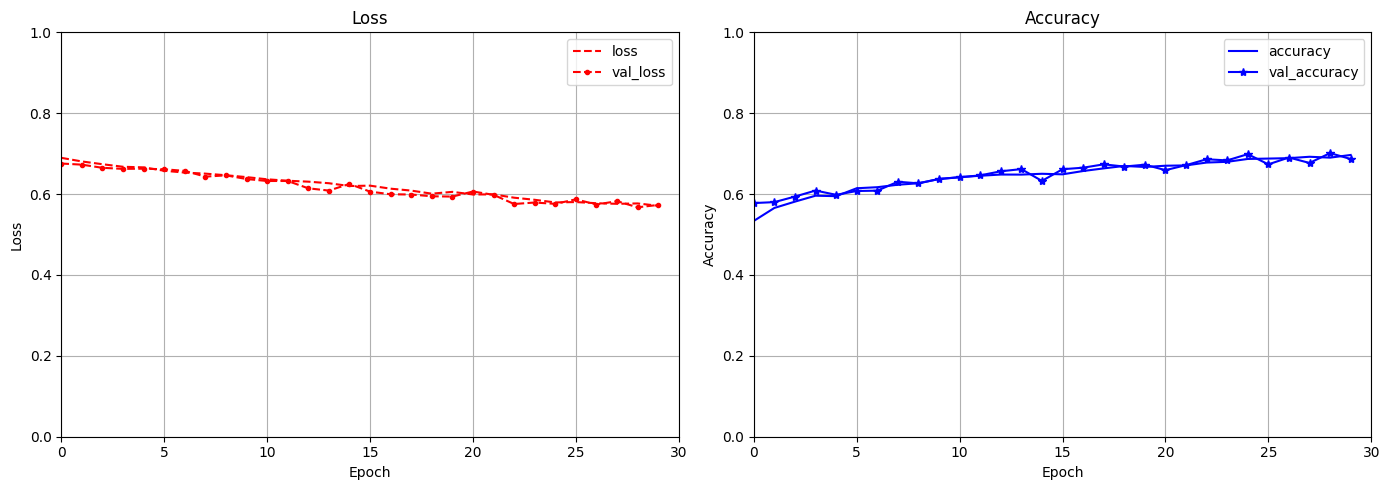

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Loss x Epoch
pd.DataFrame(history.history)[["loss", "val_loss"]].plot(
    ax=axes[0],
    xlim=[0, 30],
    ylim=[0, 1],
    grid=True,
    xlabel="Epoch",
    style=["r--", "r--."],
    title="Loss"
)
axes[0].set_ylabel("Loss")

# Gráfico 2: Accuracy x Epoch
pd.DataFrame(history.history)[["accuracy", "val_accuracy"]].plot(
    ax=axes[1],
    xlim=[0, 30],
    ylim=[0, 1],
    grid=True,
    xlabel="Epoch",
    style=["b-", "b-*"],
    title="Accuracy"
)
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

**Ao fim do treinamento da MLP podemos perceber que não temos Overfitting**

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6808 - loss: 0.5800


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


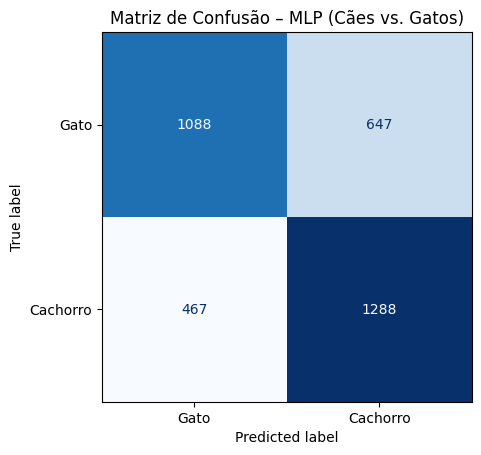

In [ ]:
# Avaliação no conjunto de teste
loss_mlp_cd, acc_mlp_cd = model.evaluate(test_set)

# Matriz de confusão da MLP (cães vs. gatos)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_true_cd = []
y_pred_cd = []
for x_batch, y_batch in test_set:
    preds = model.predict(x_batch, verbose=0)
    y_true_cd.extend(y_batch.numpy())
    y_pred_cd.extend((preds.flatten() >= 0.5).astype(int))

y_true_cd = np.array(y_true_cd)
y_pred_cd = np.array(y_pred_cd)

cm = confusion_matrix(y_true_cd, y_pred_cd)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Gato", "Cachorro"])
disp.plot(cmap="Blues", colorbar=False)
plt.title("Matriz de Confusão – MLP (Cães vs. Gatos)")
plt.show()

# Guardar histórico/métricas para comparação final
mlp_cd_history = history.history
mlp_cd_acc = acc_mlp_cd

**Agora ainda falando sobre modelos iremos implementar a LENET-5**

In [ ]:
#Lenet5
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.layers import MaxPooling2D, Dense, Conv2D, Flatten
from keras.models import Sequential
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
batch_size=128
num_classes=2
epochs=30

def build_model(optimizer):
    model=Sequential()
    model.add(Conv2D(filters=32, kernel_size=(5,5), padding='same', activation='tanh', input_shape=(28, 28, 3)))
    model.add(MaxPooling2D(strides=2))
    model.add(Conv2D(filters=48, kernel_size=(5,5), padding='valid', activation='tanh'))
    model.add(MaxPooling2D(strides=2))
    model.add(Flatten())
    model.add(Dense(120, activation='tanh'))
    model.add(Dense(84, activation='tanh'))
    model.add(Dense(1, activation="sigmoid"))


    model.compile(loss="binary_crossentropy",optimizer= optimizer, metrics=['accuracy'])
    return model

In [ ]:
model = build_model('Adam')

hist = model.fit(train_set, validation_data=valid_set, batch_size=batch_size,
                 epochs=epochs, verbose=1)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6018 - loss: 0.6643 - val_accuracy: 0.6604 - val_loss: 0.6132
Epoch 2/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6905 - loss: 0.5852 - val_accuracy: 0.7214 - val_loss: 0.5452
Epoch 3/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7200 - loss: 0.5456 - val_accuracy: 0.7131 - val_loss: 0.5543
Epoch 4/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7432 - loss: 0.5188 - val_accuracy: 0.7423 - val_loss: 0.5163
Epoch 5/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7567 - loss: 0.4954 - val_accuracy: 0.7839 - val_loss: 0.4598
Epoch 6/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7680 - loss: 0.4798 - val_accuracy: 0.7833 - val_loss: 0.4652
Epoch 7/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7864 - loss: 0.4491 - val_accuracy: 0.8048 - val_loss: 0.4160
Epoch 8/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.8099 - loss: 0.4167 - val_accuracy: 0.8249 - val_loss: 0.3893
Epoch 9/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8205 - loss: 0.3935 - val_accuracy: 0.8309 - val

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9885 - loss: 0.0408


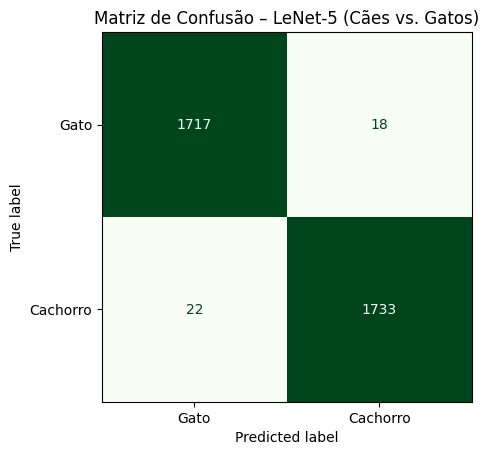

In [ ]:
# Avaliação no conjunto de teste
loss_lenet_cd, acc_lenet_cd = model.evaluate(test_set)

# Matriz de confusão da LeNet-5 (cães vs. gatos)
y_true_cd = []
y_pred_cd = []
for x_batch, y_batch in test_set:
    preds = model.predict(x_batch, verbose=0)
    y_true_cd.extend(y_batch.numpy())
    y_pred_cd.extend((preds.flatten() >= 0.5).astype(int))

y_true_cd = np.array(y_true_cd)
y_pred_cd = np.array(y_pred_cd)

cm = confusion_matrix(y_true_cd, y_pred_cd)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Gato", "Cachorro"])
disp.plot(cmap="Greens", colorbar=False)
plt.title("Matriz de Confusão – LeNet-5 (Cães vs. Gatos)")
plt.show()

# Guardar histórico/métricas para comparação final
lenet_cd_history = hist.history
lenet_cd_acc = acc_lenet_cd

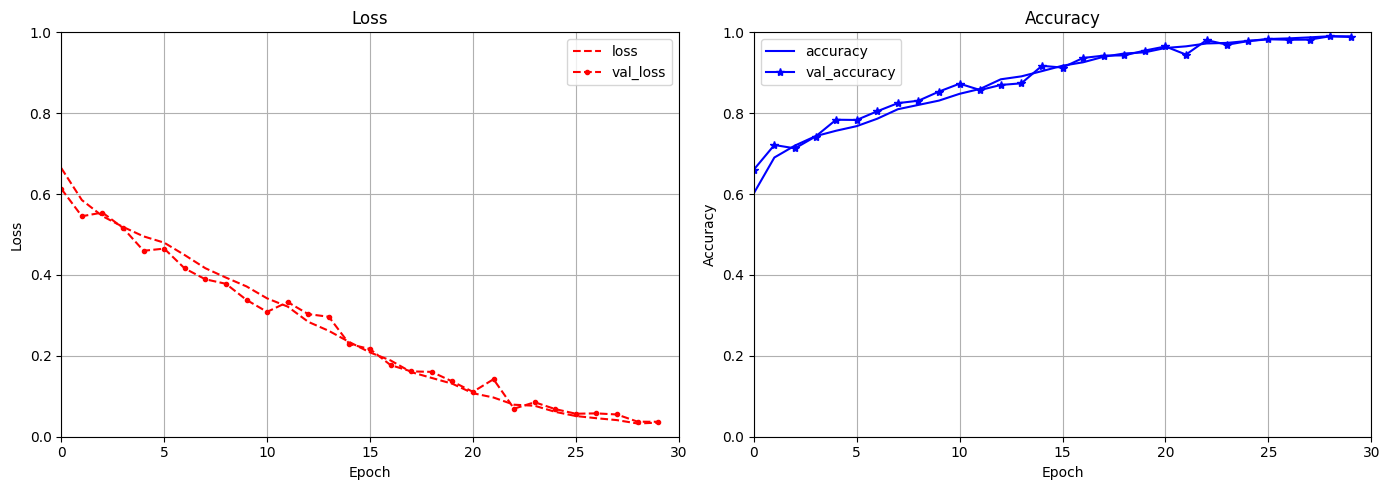

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Loss x Epoch
pd.DataFrame(hist.history)[["loss", "val_loss"]].plot(
    ax=axes[0],
    xlim=[0, 30],
    ylim=[0, 1],
    grid=True,
    xlabel="Epoch",
    style=["r--", "r--."],
    title="Loss"
)
axes[0].set_ylabel("Loss")

# Gráfico 2: Accuracy x Epoch
pd.DataFrame(hist.history)[["accuracy", "val_accuracy"]].plot(
    ax=axes[1],
    xlim=[0, 30],
    ylim=[0, 1],
    grid=True,
    xlabel="Epoch",
    style=["b-", "b-*"],
    title="Accuracy"
)
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

## **2) Reconhecimento de emoções faciais**

### **O problema**

O objetivo é construir e treinar uma RNA MLP e uma CNN LeNet-5 para classificar imagens de rostos em uma das sete categorias de emoção (raiva, nojo, medo, felicidade, tristeza, surpresa, neutro). Deve ser apresentada a comparação de resultados e uma justificativa baseada nos dados e resultados para a escolha de uma das abordagens.

### **O Conjunto de dados**

Utilizaremos o dataset **FER-2013 (Facial Expression Recognition 2013)**, disponível no [Kaggle](https://www.kaggle.com/datasets/msambare/fer2013). Mais informações sobre a base podem ser encontradas no artigo [*State of the Art Performance on FER2013*](https://arxiv.org/pdf/2105.03588).


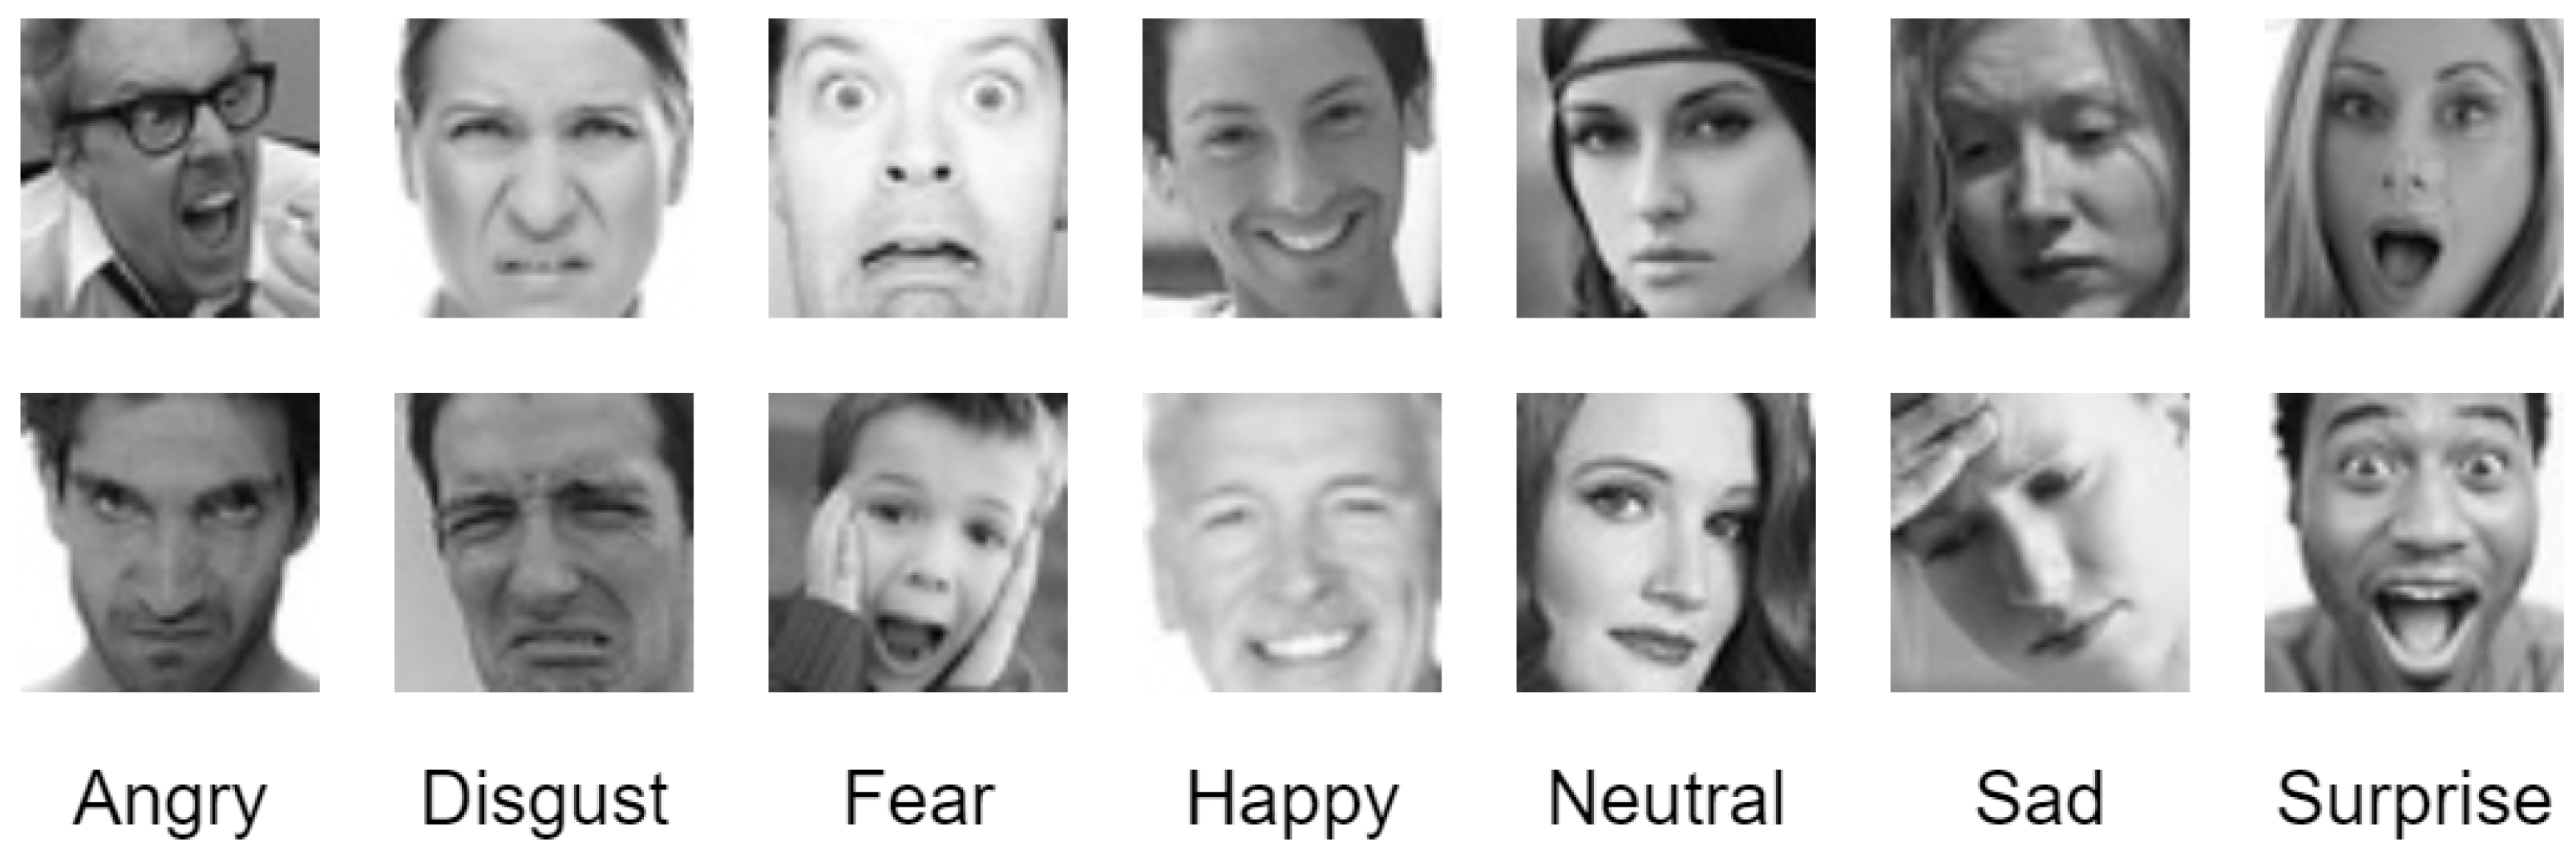

# 1 - EDA

**Primeiros importaremos o dataset do Kaggle**

In [ ]:
import kagglehub

path = kagglehub.dataset_download("msambare/fer2013")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013


**Apesar do dataset já vir dividido entre treino e teste, iremos concatenar os dois em um único dataset, para fazermos nossa própia divisão depois, seguindo o mesmo método usado no problema dos cachorros e dos gatos**

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/fer2013/train",
    image_size=(48, 48),
    color_mode="grayscale",
    batch_size=32,
    label_mode="int",
    shuffle=True,
    seed=42
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/fer2013/test",
    image_size=(48, 48),
    color_mode="grayscale",
    batch_size=32,
    label_mode="int",
    shuffle=True,
    seed=42
)
dataset = train_ds.concatenate(test_ds)
dataset

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.


<_ConcatenateDataset element_spec=(TensorSpec(shape=(None, 48, 48, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

**Em seguida iremos observar a distribuição das 7 classes no dataset concatenado já com todas as imagens**

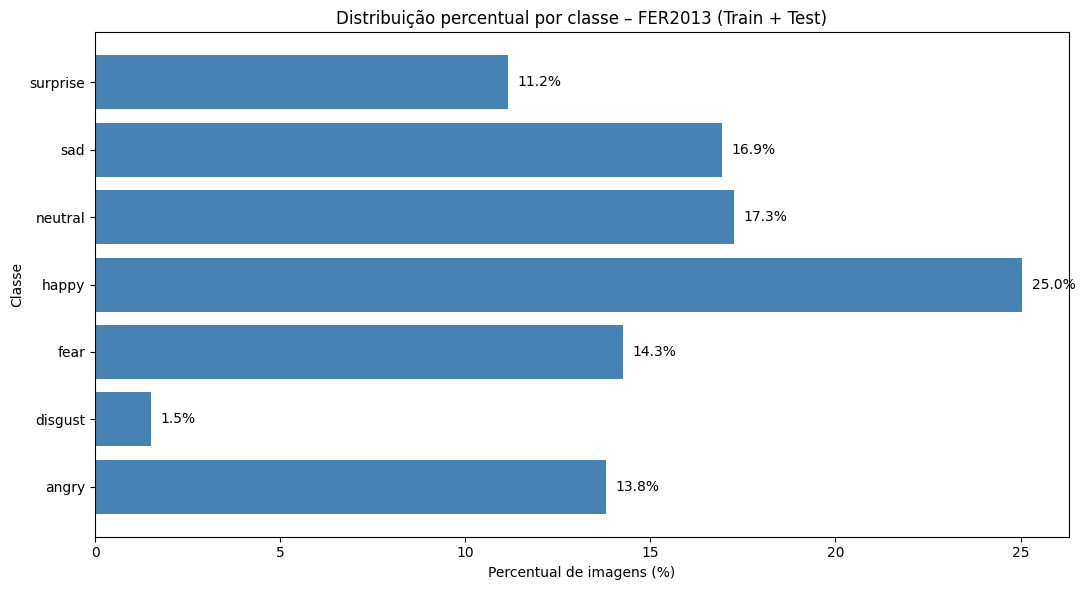

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class_names = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

num_classes = len(class_names)

counts = np.zeros(num_classes, dtype=int)

for _, labels in dataset.unbatch():
    counts[int(labels.numpy())] += 1

total = counts.sum()
percentages = (counts / total) * 100

plt.figure(figsize=(11, 6))
plt.barh(class_names, percentages, color="steelblue")

plt.xlabel("Percentual de imagens (%)")
plt.ylabel("Classe")
plt.title("Distribuição percentual por classe – FER2013 (Train + Test)")

for i, p in enumerate(percentages):
    plt.text(p + max(percentages) * 0.01, i, f"{p:.1f}%", va="center")

plt.tight_layout()
plt.show()

**É notável o desbalanceamento do problema, especialmente quando olhamos para a classe "disgust", isso irá impactar na métrica que iremos escolher como alvo no treinamento, entre outras coisas como o uso de CLASS WEIGHTS como forma de tentar atenuar esse desbalanceamento**

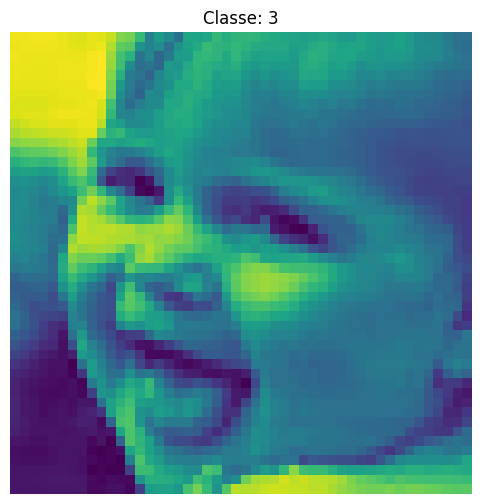

Shape da imagem: (48, 48, 1)


In [ ]:
for images, labels in dataset.take(1):
    imagem = images[0].numpy()
    label = labels[0].numpy()

    plt.figure(figsize=(6, 6))
    plt.imshow(imagem.astype("uint8"))
    plt.title(f"Classe: {label}")
    plt.axis("off")
    plt.show()

    print(f"Shape da imagem: {imagem.shape}")

**Em seguida iremos dividir os dados entre treino, teste e validação seguindo o mesmo método que utilizamos no problema de cachorros e gatos**

In [ ]:
with tf.device('/CPU:0'):
    dataset = dataset.unbatch()
    def contar(dataset):
        return dataset.reduce(
            tf.constant(0, dtype=tf.int64),
            lambda x, _: x + 1
        ).numpy()
    total_dataset_size = contar(dataset)
    train_size = int(0.7 * total_dataset_size)
    test_size = int(0.15 * total_dataset_size)
    valid_size = int(0.15 * total_dataset_size)
    print(f"Total: {total_dataset_size}")
    print(f"Treino: {train_size}, Validação: {valid_size}, Teste: {test_size}")

    data = dataset.shuffle(10_000, seed=42)
    train_set = data.take(train_size)
    remaining = data.skip(train_size)
    val_set = remaining.take(valid_size)
    test_set = remaining.skip(valid_size)
    print("\nTamanhos após divisão:")
    print(f"Treino: {contar(train_set)}")
    print(f"Validação: {contar(val_set)}")
    print(f"Teste: {contar(test_set)}")

Total: 35887
Treino: 25120, Validação: 5383, Teste: 5383

Tamanhos após divisão:
Treino: 25120
Validação: 5383
Teste: 5384


**Agora iremos verificar se a divisão aleatória preservou minimamente a distribuição original dos dados, vale lembrar que pequenas variações são aceitáveis, pois não irão impactar muito o treinamento nem a avaliação do modelo**

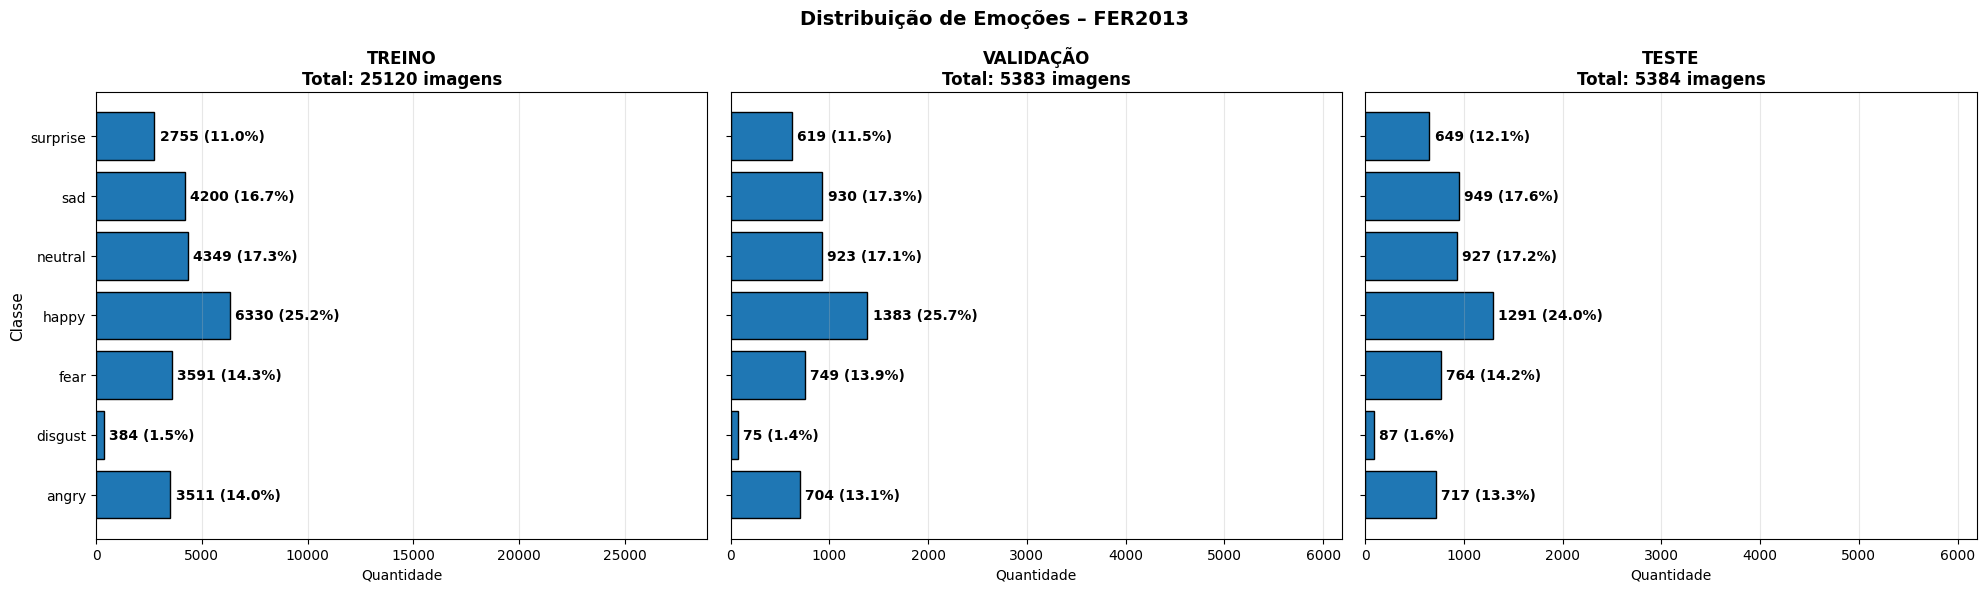

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
class_names = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]
num_classes = len(class_names)
def contar_labels_faces(dataset, num_classes=7):
    counts = np.zeros(num_classes, dtype=int)
    for _, label in dataset:
        counts[int(label.numpy())] += 1
    return counts
train_counts = contar_labels_faces(train_set, num_classes)
val_counts   = contar_labels_faces(val_set, num_classes)
test_counts  = contar_labels_faces(test_set, num_classes)
train_total = train_counts.sum()
val_total   = val_counts.sum()
test_total  = test_counts.sum()
train_pct = (train_counts / train_total) * 100
val_pct   = (val_counts / val_total) * 100
test_pct  = (test_counts / test_total) * 100
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

conjuntos = [
    ("TREINO",    train_counts, train_pct, train_total),
    ("VALIDAÇÃO", val_counts,   val_pct,   val_total),
    ("TESTE",     test_counts,  test_pct,  test_total)
]

for ax, (titulo, counts, pcts, total) in zip(axes, conjuntos):
    ax.barh(class_names, counts, edgecolor="black")
    ax.set_title(f"{titulo}\nTotal: {total} imagens", fontweight="bold", fontsize=12)
    ax.set_xlabel("Quantidade")

    # Adicionar valores + percentuais
    for i, (v, p) in enumerate(zip(counts, pcts)):
        ax.text(
            v + total * 0.01,
            i,
            f"{v} ({p:.1f}%)",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

    ax.set_xlim(0, total * 1.15)
    ax.grid(axis="x", alpha=0.3)

axes[0].set_ylabel("Classe", fontsize=11)
plt.suptitle("Distribuição de Emoções – FER2013", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Agora de forma similar ao que fizemos no problema dos cachorros e dos gatos iremos procurar pro imagens pequenas que não agregam em nada ao modelo**

🔍 Procurando dimensões extremas no conjunto de treino...
⏳ Isso pode levar alguns segundos...

📊 RESULTADOS DAS DIMENSÕES EXTREMAS

📏 MENOR DIMENSÃO:
   Altura: 48 pixels
   Largura: 48 pixels
   Emoção: surprise
   Total de amostras analisadas: 25120

📐 MAIOR DIMENSÃO:
   Altura: 48 pixels
   Largura: 48 pixels
   Emoção: surprise


/tmp/ipykernel_8089/2513940745.py:132: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8089/2513940745.py:132: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


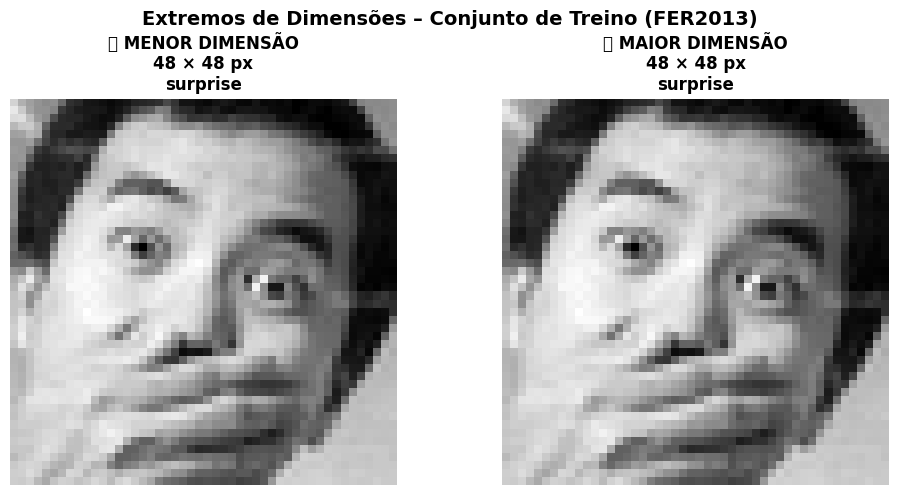

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class_names = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

def encontrar_dimensoes_extremas_faces(dataset, num_amostras=None):
    menor_altura = float("inf")
    menor_largura = float("inf")
    maior_altura = 0
    maior_largura = 0

    imagem_menor = None
    imagem_maior = None
    label_menor = None
    label_maior = None

    total = 0

    for imagem, label in dataset:
        # Obter dimensões da imagem
        altura = imagem.shape[0]
        largura = imagem.shape[1]

        # Verificar menor dimensão
        if altura < menor_altura or largura < menor_largura:
            menor_altura = altura
            menor_largura = largura
            imagem_menor = imagem
            label_menor = int(label.numpy())

        # Verificar maior dimensão
        if altura > maior_altura or largura > maior_largura:
            maior_altura = altura
            maior_largura = largura
            imagem_maior = imagem
            label_maior = int(label.numpy())

        total += 1

        # Limitar número de amostras (opcional)
        if num_amostras and total >= num_amostras:
            break

    return {
        "menor": {
            "altura": menor_altura,
            "largura": menor_largura,
            "imagem": imagem_menor,
            "label": label_menor
        },
        "maior": {
            "altura": maior_altura,
            "largura": maior_largura,
            "imagem": imagem_maior,
            "label": label_maior
        },
        "total_analisado": total
    }

# ============================================
# EXECUTAR NO CONJUNTO DE TREINO
# ============================================
print("🔍 Procurando dimensões extremas no conjunto de treino...")
print("⏳ Isso pode levar alguns segundos...\n")

resultados = encontrar_dimensoes_extremas_faces(train_set)

# ============================================
# EXIBIR RESULTADOS NUMÉRICOS
# ============================================
print("=" * 60)
print("📊 RESULTADOS DAS DIMENSÕES EXTREMAS")
print("=" * 60)

print("\n📏 MENOR DIMENSÃO:")
print(f"   Altura: {resultados['menor']['altura']} pixels")
print(f"   Largura: {resultados['menor']['largura']} pixels")
print(f"   Emoção: {class_names[resultados['menor']['label']]}")
print(f"   Total de amostras analisadas: {resultados['total_analisado']}")

print("\n📐 MAIOR DIMENSÃO:")
print(f"   Altura: {resultados['maior']['altura']} pixels")
print(f"   Largura: {resultados['maior']['largura']} pixels")
print(f"   Emoção: {class_names[resultados['maior']['label']]}")

# ============================================
# VISUALIZAR AS IMAGENS ENCONTRADAS
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Imagem menor
if resultados["menor"]["imagem"] is not None:
    axes[0].imshow(
        resultados["menor"]["imagem"].numpy().squeeze(),
        cmap="gray"
    )
    axes[0].set_title(
        f"🟢 MENOR DIMENSÃO\n"
        f"{resultados['menor']['altura']} × {resultados['menor']['largura']} px\n"
        f"{class_names[resultados['menor']['label']]}",
        fontweight="bold"
    )
    axes[0].axis("off")

# Imagem maior
if resultados["maior"]["imagem"] is not None:
    axes[1].imshow(
        resultados["maior"]["imagem"].numpy().squeeze(),
        cmap="gray"
    )
    axes[1].set_title(
        f"🔴 MAIOR DIMENSÃO\n"
        f"{resultados['maior']['altura']} × {resultados['maior']['largura']} px\n"
        f"{class_names[resultados['maior']['label']]}",
        fontweight="bold"
    )
    axes[1].axis("off")

plt.suptitle(
    "Extremos de Dimensões – Conjunto de Treino (FER2013)",
    fontsize=14,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

**Neste problema diferentemente do problema do cachorro e gato as imagens já estão todas no formato 48x48 pixels no grayscale(1 canal).Portanto não há necessidade de eliminar nenhuma imagem pois nenhuma é tão pequena a ponto de ser menor que a entrada das nossas redes : 28x28**

**Devido ao forte desbalanceamento, iremos usar class weights, ou seja cada classe tenho um peso no aprendizado do modelo, classes com menos instâncias no treino receberão um peso maior do que classes com mais instâncias por meio da seguinte conta:**   
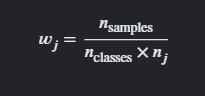

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
labels_train = []

for _, label in train_set:
    labels_train.append(int(label.numpy()))

labels_train = np.array(labels_train)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels_train),
    y=labels_train
)
class_weights = {
    i: weight for i, weight in zip(np.unique(labels_train), class_weights_array)
}

print("Class weights calculados:")
for k, v in class_weights.items():
    print(f"Classe {k}: {v:.3f}")

Class weights calculados:
Classe 0: 1.039
Classe 1: 9.178
Classe 2: 1.000
Classe 3: 0.568
Classe 4: 0.824
Classe 5: 0.845
Classe 6: 1.299


# 2 - Pré-processamento

**Agora iremos realizar o pré-processamento das imagens para prepará-las para o modelo, o processo será o mesmo do dataset dos cachorros e gatos**

In [ ]:
# Função para extrair imagem, label E normalizar
def preprocess_image_faces(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.resize(image, [28, 28])
    return image, label

In [ ]:
# Aplicar o pré-processamento
train_set = train_set.map(preprocess_image_faces)
val_set = val_set.map(preprocess_image_faces)
test_set = test_set.map(preprocess_image_faces)

**Aqui vem a primeira diferença entre esse problema e o problema dos cachorros e gatos: iremos usar um tamanho de batch de 64, pois durante as nossas tentativas de treinamento estavamos encontrando o treinamento bem instável, e uma das formas de corrigir essa instabilidade é diminuir o tamanho do batch[2]. Fora isso o processo é o mesmo do problema dos cachorros e gatos: embaralhar,dividir em batch usando a pré-busca**

In [ ]:
# Configurar os datasets com batch
with tf.device('/CPU:0'):
    train_set = train_set.shuffle(10_000, seed=42).batch(64).prefetch(tf.data.AUTOTUNE)
    valid_set = val_set.batch(64).cache().prefetch(tf.data.AUTOTUNE)
    test_set = test_set.batch(64).cache().prefetch(tf.data.AUTOTUNE)

# 3 - Modelos

**Mais a frente durante o treinamento da Lenet para esse problema estavamos encontrando muitas instabilidades no treinamento e até mesmo em algumas execuções com mais épocas um overfitting forte, portanto visando atenuar isso e com base nas configurações da CNN do artigo que usa o estado da arte[3], fizemos diversas modificações de implementação da LENET:**
- Cronograma da taxa de aprendizado: ReduceLROnPlateau
- EarlyStopping: um early stopping customizado para monitorar o f1_macro durante o treinamento e interromper o treinamento caso o f1_macro de treino e validação comecem a se distanciar

Apesar disso, agora em seguida vem a MLP desse problema, modelos em que não tivemos esse tipo de problema portanto nada disso será usado na MLP apenas na LENET

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

lr = ReduceLROnPlateau(
    monitor='val_f1_macro',
    factor=0.75,
    patience=5,
    min_lr=1e-6,
    mode='max'
)


class F1GapEarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, threshold=0.1, patience=3):
        super().__init__()
        self.threshold = threshold
        self.patience = patience
        self.wait = 0

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        train_f1 = logs.get("f1_macro")
        val_f1 = logs.get("val_f1_macro")

        if train_f1 is None or val_f1 is None:
            return

        gap = abs(train_f1 - val_f1)

        print(f"📊 Gap F1: {gap:.4f}")

        if gap > self.threshold:
            self.wait += 1
            print(f"⚠️ Gap alto ({self.wait}/{self.patience})")

            if self.wait >= self.patience:
                print("🛑 Early stopping: overfitting detectado (gap alto)")
                self.model.stop_training = True
        else:
            self.wait = 0

early_stopping = F1GapEarlyStopping(
    threshold=0.03,
    patience=3
)


**A MLP tem a mesma arquitetura da utilizada no problema dos cachorros e gatos, com excessão da camada de entrada Flatten, pois neste problema as entradas tem apenas 1 canal o que faz com que a rede inteira de maneira geral tenha bem menos parâmetros do que a MLP do problema dos cachorros e gatos**

In [ ]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(7, activation="softmax"),
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 7)              │            63 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,543 (435.71 KB)

 Trainable params: 111,543 (435.71 KB)

 Non-trainable params: 0 (0.00 B)

**Aqui estamos criando uma métrica customizada de F1_macro para usar, usaremos f1_macro pois como estamos diante de um problema desbalanceado, esta é a métrica mais geral para acompanhar o desempenho do treinamento sem olhar para classes específicas**

In [ ]:
class SparseF1Macro(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name="f1_macro", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes

        self.tp = self.add_weight(shape=(num_classes,), initializer="zeros")
        self.fp = self.add_weight(shape=(num_classes,), initializer="zeros")
        self.fn = self.add_weight(shape=(num_classes,), initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)

        y_true_onehot = tf.one_hot(y_true, depth=self.num_classes)
        y_pred_onehot = tf.one_hot(y_pred, depth=self.num_classes)

        tp = tf.reduce_sum(y_true_onehot * y_pred_onehot, axis=0)
        fp = tf.reduce_sum((1 - y_true_onehot) * y_pred_onehot, axis=0)
        fn = tf.reduce_sum(y_true_onehot * (1 - y_pred_onehot), axis=0)

        self.tp.assign_add(tp)
        self.fp.assign_add(fp)
        self.fn.assign_add(fn)

    def result(self):
        precision = tf.math.divide_no_nan(self.tp, self.tp + self.fp)
        recall = tf.math.divide_no_nan(self.tp, self.tp + self.fn)
        f1 = tf.math.divide_no_nan(2 * precision * recall, precision + recall)
        return tf.reduce_mean(f1)

    def reset_state(self):
        for var in self.variables:
            var.assign(tf.zeros_like(var))

**Aqui vamos treinar a MLP, porém utilizamos 2 coisas a mais importantes: decaimento de peso com regularização e um número específico de momentum, essas configurações do ADAM foram retiradas de [2] e portanto também utilizaremos esses hiperparâmetros do ADAM na LENET**

In [ ]:
optimizer = tf.keras.optimizers.Adam(weight_decay=0.0001,ema_momentum=0.9,use_ema=True)

f1_macro = SparseF1Macro(num_classes=7)

model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
        metrics=[f1_macro])
history = model.fit(train_set, validation_data=valid_set, epochs=30,class_weight=class_weights)

Epoch 1/30
    353/Unknown 2s 1ms/step - f1_macro: 0.1042 - loss: 1.9403

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - f1_macro: 0.1116 - loss: 1.9446 - val_f1_macro: 0.0741 - val_loss: 1.9498
Epoch 2/30
393/393 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_macro: 0.0812 - loss: 1.9396 - val_f1_macro: 0.0986 - val_loss: 1.9401
Epoch 3/30
393/393 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_macro: 0.0903 - loss: 1.9168 - val_f1_macro: 0.0933 - val_loss: 1.9269
Epoch 4/30
393/393 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_macro: 0.1101 - loss: 1.9058 - val_f1_macro: 0.1630 - val_loss: 1.8955
Epoch 5/30
393/393 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_macro: 0.1942 - loss: 1.8515 - val_f1_macro: 0.1942 - val_loss: 1.8443
Epoch 6/30
393/393 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - f1_macro: 0.2107 - loss: 1.8265 - val_f1_macro: 0.2088 - val_loss: 1.8181
Epoch 7/30
393/393 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - f1_macro: 0.2198 - loss: 1.8151 - val_f1_macro: 0.2090 - val_loss: 1.8309
Epoch 8/30
393/393 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_macro: 0.2236 - loss: 1.7987 - val_f1_macro: 0.2390 - val_

In [ ]:
model.evaluate(test_set)

85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 635us/step - f1_macro: 0.2716 - loss: 1.6987


[1.698670744895935, 0.2715819776058197]

              precision    recall  f1-score   support

       angry       0.23      0.07      0.11       724
     disgust       0.06      0.71      0.12        82
        fear       0.17      0.06      0.08       759
       happy       0.55      0.44      0.49      1346
     neutral       0.34      0.26      0.30       943
         sad       0.27      0.37      0.31       906
    surprise       0.40      0.62      0.48       624

    accuracy                           0.32      5384
   macro avg       0.29      0.36      0.27      5384
weighted avg       0.35      0.32      0.31      5384



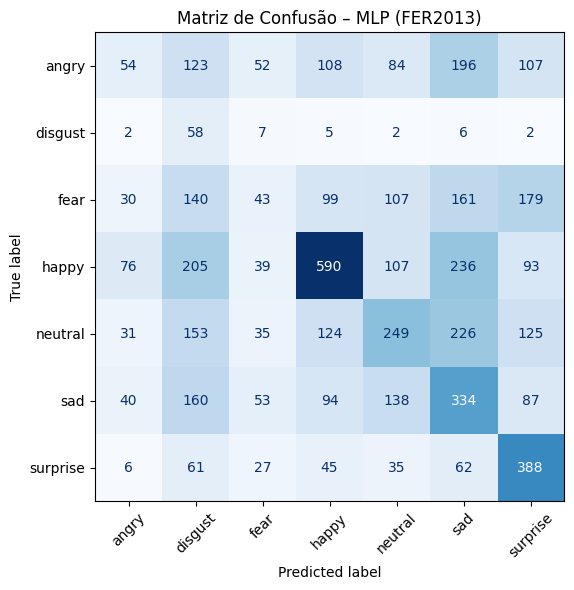

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for x_batch, y_batch in test_set:
    preds = model.predict(x_batch, verbose=0)

    y_true.extend(y_batch.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_names = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

print(classification_report(y_true, y_pred, target_names=class_names))

# Matriz de confusão da MLP (FER2013)
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", colorbar=False, xticks_rotation=45, ax=ax)
ax.set_title("Matriz de Confusão – MLP (FER2013)")
plt.tight_layout()
plt.show()

# Guardar para comparação final
mlp_fer_y_true = y_true
mlp_fer_y_pred = y_pred
mlp_fer_history = history.history

**Podemos perceber que a performance da MLP nesse problema é bem menor que a performance do problema dos cachorros e dos gatos, resultado esperado visto que estamos diante de um problema bem mais complexo que o anterior**

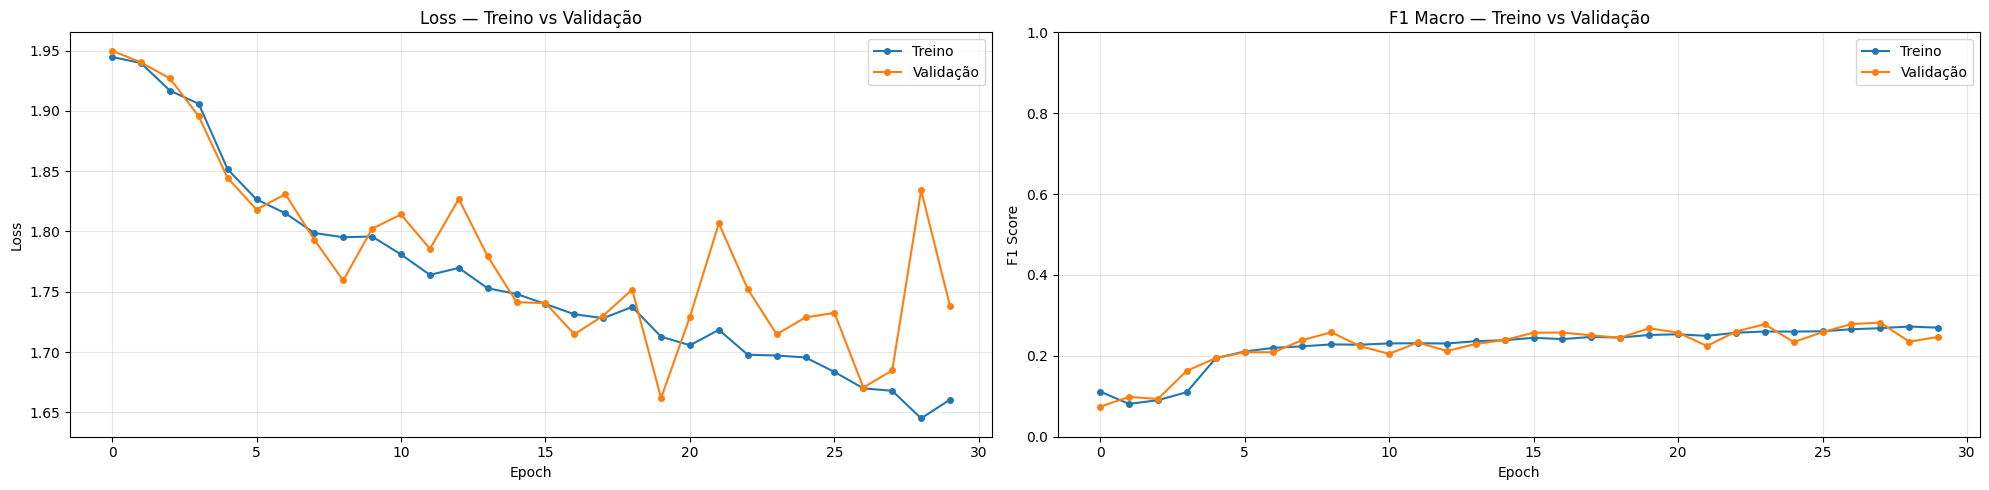

In [ ]:
import matplotlib.pyplot as plt

class_names = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# =========================
# 🔹 1. LOSS
# =========================
ax = axes[0]
ax.plot(history.history["loss"], label="Treino", marker='o', markersize=4)
ax.plot(history.history["val_loss"], label="Validação", marker='o', markersize=4)

ax.set_title("Loss — Treino vs Validação")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)


# =========================
# 🔹 2. F1 Macro
# =========================
ax = axes[1]
ax.plot(history.history["f1_macro"], label="Treino", marker='o', markersize=4)
ax.plot(history.history["val_f1_macro"], label="Validação", marker='o', markersize=4)

ax.set_title("F1 Macro — Treino vs Validação")
ax.set_xlabel("Epoch")
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("metricas_completas.png", dpi=150)
plt.show()

In [ ]:
#Lenet5
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.layers import MaxPooling2D, Dense, Conv2D, Flatten
from keras.models import Sequential
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

**Finalmente entramos na LENET desse problema, utilizamos 15 epochs, o que será explicado na conclussão.**

In [ ]:
batch_size=64
num_classes=7
epochs=15

def build_model(optimizer):
    model=Sequential()
    model.add(Conv2D(filters=32, kernel_size=(5,5), padding='same', activation='tanh', input_shape=(28, 28, 1)))
    model.add(MaxPooling2D(strides=2))
    model.add(Conv2D(filters=48, kernel_size=(5,5), padding='valid', activation='tanh'))
    model.add(MaxPooling2D(strides=2))
    model.add(Flatten())
    model.add(Dense(120, activation='tanh'))
    model.add(Dense(84, activation='tanh'))
    model.add(Dense(7, activation="softmax"))


    model.compile(loss="sparse_categorical_crossentropy",optimizer=optimizer, metrics=[f1_macro])
    return model

In [ ]:
optimizer = tf.keras.optimizers.Adam(weight_decay=0.0001,ema_momentum=0.9,use_ema=True)
model = build_model(optimizer)

hist = model.fit(train_set, validation_data=valid_set, batch_size=batch_size,class_weight=class_weights,
                 epochs=epochs,callbacks=[lr,early_stopping], verbose=1)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


    385/Unknown 2s 3ms/step - f1_macro: 0.2509 - loss: 1.8402📊 Gap F1: 0.0660
⚠️ Gap alto (1/3)
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - f1_macro: 0.2706 - loss: 1.7585 - val_f1_macro: 0.3366 - val_loss: 1.5370 - learning_rate: 0.0010
Epoch 2/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


391/393 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_macro: 0.3362 - loss: 1.5991📊 Gap F1: 0.0344
⚠️ Gap alto (2/3)
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - f1_macro: 0.3380 - loss: 1.5976 - val_f1_macro: 0.3724 - val_loss: 1.5189 - learning_rate: 0.0010
Epoch 3/15
384/393 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_macro: 0.3721 - loss: 1.4809📊 Gap F1: 0.0192
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - f1_macro: 0.3732 - loss: 1.4926 - val_f1_macro: 0.3923 - val_loss: 1.5147 - learning_rate: 0.0010
Epoch 4/15
388/393 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_macro: 0.4069 - loss: 1.4028📊 Gap F1: 0.0064
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - f1_macro: 0.4085 - loss: 1.3936 - val_f1_macro: 0.4149 - val_loss: 1.3638 - learning_rate: 0.0010
Epoch 5/15
387/393 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - f1_macro: 0.4351 - loss: 1.3102📊 Gap F1: 0.0012
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - f1_macro: 0.4367 - loss: 1.3074 - val_f1_macro: 0.4379 - val_loss: 1.3929 - learning_rate: 0.0010
Epoch 6/15
391/393 ━━

In [ ]:
model.evaluate(test_set)

85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - f1_macro: 0.5956 - loss: 1.0640


[1.063989281654358, 0.5955620408058167]

              precision    recall  f1-score   support

       angry       0.48      0.60      0.53       724
     disgust       0.39      0.90      0.54        82
        fear       0.49      0.53      0.51       759
       happy       0.83      0.70      0.76      1346
     neutral       0.60      0.54      0.57       943
         sad       0.52      0.47      0.49       906
    surprise       0.74      0.81      0.77       624

    accuracy                           0.61      5384
   macro avg       0.58      0.65      0.60      5384
weighted avg       0.62      0.61      0.61      5384



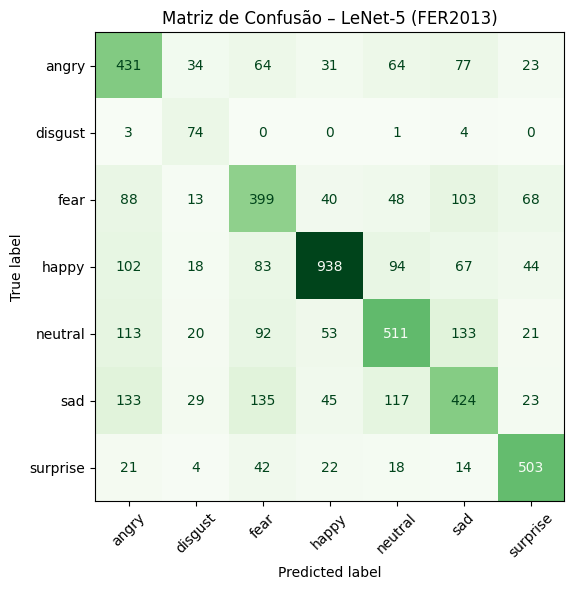

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for x_batch, y_batch in test_set:
    preds = model.predict(x_batch, verbose=0)

    y_true.extend(y_batch.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_names = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

print(classification_report(y_true, y_pred, target_names=class_names))

# Matriz de confusão da LeNet-5 (FER2013)
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Greens", colorbar=False, xticks_rotation=45, ax=ax)
ax.set_title("Matriz de Confusão – LeNet-5 (FER2013)")
plt.tight_layout()
plt.show()

# Guardar para comparação final
lenet_fer_y_true = y_true
lenet_fer_y_pred = y_pred
lenet_fer_history = hist.history

**Obtivemos no final um bom resultado, considerando principalmente a performance atingida em [2]. A seguir mostramos as curvas de Loss e F1 macro da LeNet no FER2013 e, na sequência, um resumo comparativo entre MLP e LeNet-5 nos dois problemas.**

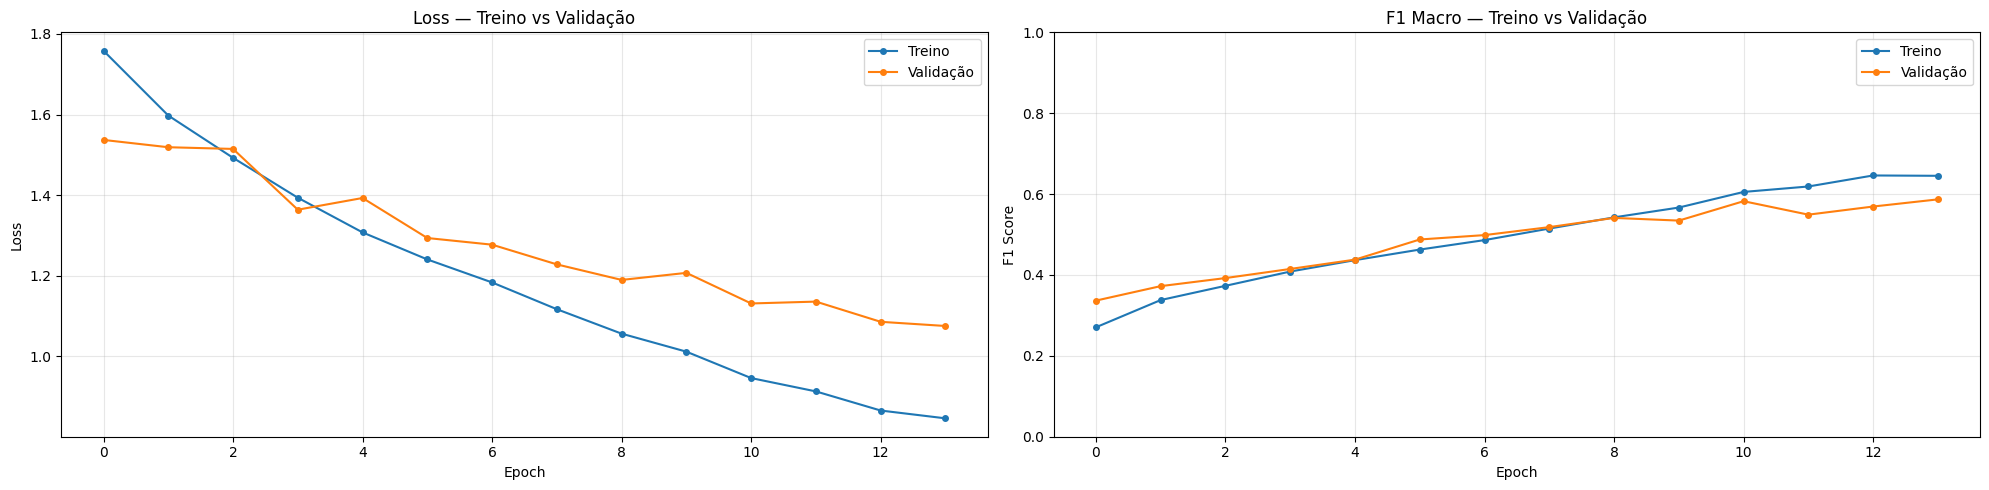

RESUMO FINAL
Problema 1 (Cães vs Gatos) — Accuracy:
  MLP    : 0.6808
  LeNet-5: 0.9885

Problema 2 (FER2013) — F1 macro:
  MLP    : 0.2716
  LeNet-5: 0.5956


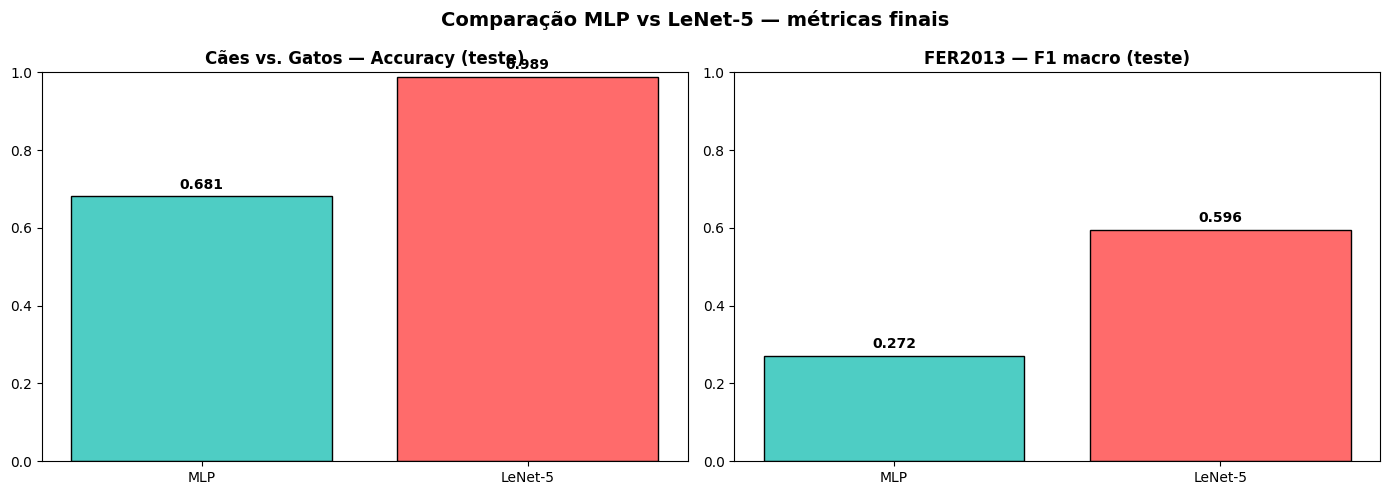

In [ ]:
class_names = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# =========================
# 🔹 1. LOSS
# =========================
ax = axes[0]
ax.plot(hist.history["loss"], label="Treino", marker='o', markersize=4)
ax.plot(hist.history["val_loss"], label="Validação", marker='o', markersize=4)

ax.set_title("Loss — Treino vs Validação")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)


# =========================
# 🔹 2. F1 Macro
# =========================
ax = axes[1]
ax.plot(hist.history["f1_macro"], label="Treino", marker='o', markersize=4)
ax.plot(hist.history["val_f1_macro"], label="Validação", marker='o', markersize=4)

ax.set_title("F1 Macro — Treino vs Validação")
ax.set_xlabel("Epoch")
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("metricas_completas.png", dpi=150)
plt.show()


# =========================================================
# COMPARAÇÃO FINAL — MLP vs LeNet-5 nos dois problemas
# =========================================================
from sklearn.metrics import f1_score

# Problema 1 (cães vs. gatos): comparamos pela accuracy de teste
acc_mlp_p1   = mlp_cd_acc
acc_lenet_p1 = lenet_cd_acc

# Problema 2 (FER2013): comparamos pelo f1_macro de teste
f1_mlp_p2   = f1_score(mlp_fer_y_true,   mlp_fer_y_pred,   average="macro")
f1_lenet_p2 = f1_score(lenet_fer_y_true, lenet_fer_y_pred, average="macro")

print("RESUMO FINAL")
print("="*50)
print(f"Problema 1 (Cães vs Gatos) — Accuracy:")
print(f"  MLP    : {acc_mlp_p1:.4f}")
print(f"  LeNet-5: {acc_lenet_p1:.4f}")
print()
print(f"Problema 2 (FER2013) — F1 macro:")
print(f"  MLP    : {f1_mlp_p2:.4f}")
print(f"  LeNet-5: {f1_lenet_p2:.4f}")

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(["MLP", "LeNet-5"], [acc_mlp_p1, acc_lenet_p1],
            color=["#4ECDC4", "#FF6B6B"], edgecolor="black")
axes[0].set_title("Cães vs. Gatos — Accuracy (teste)", fontweight="bold")
axes[0].set_ylim(0, 1)
for i, v in enumerate([acc_mlp_p1, acc_lenet_p1]):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

axes[1].bar(["MLP", "LeNet-5"], [f1_mlp_p2, f1_lenet_p2],
            color=["#4ECDC4", "#FF6B6B"], edgecolor="black")
axes[1].set_title("FER2013 — F1 macro (teste)", fontweight="bold")
axes[1].set_ylim(0, 1)
for i, v in enumerate([f1_mlp_p2, f1_lenet_p2]):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

plt.suptitle("Comparação MLP vs LeNet-5 — métricas finais", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Conclusões

**Concluímos que, nos dois problemas, a CNN teve um desempenho bem melhor do que a MLP. Isso ficou bem claro principalmente no segundo problema (FER2013), onde o F1 macro da CNN foi mais que o dobro do que a MLP conseguiu. Mais uma vez, isso mostra que para problemas com imagens a CNN leva vantagem, e já era algo que esperávamos, já que ela consegue enxergar padrões espaciais e hierarquias nas imagens, enquanto a MLP acaba tratando cada pixel de forma isolada e perde a noção de onde cada coisa está.

Vale dizer também que não conseguimos rodar os modelos várias vezes nem fazer uma busca completa de hiperparâmetros, porque tivemos poucos créditos disponíveis durante o trabalho. Por isso, o número de execuções foi bem limitado. Mesmo assim, os resultados que obtivemos foram consistentes e apontaram sempre na mesma direção.

Olhando para os classification_report da LeNet no FER2013, as classes que se mostraram mais difíceis foram "fear" (medo) e "sad" (tristeza), com F1 score próximo de 0.50, abaixo das demais. Acreditamos que isso aconteça por causa da confusão entre emoções com expressões faciais parecidas, como medo e tristeza, ou pela própria qualidade/variabilidade das imagens dessas classes no dataset. Já as classes "happy" e "surprise" foram as mais fáceis para o modelo, com F1 acima de 0.75. Já no problema de cães vs. gatos, que era mais simples, os dois modelos tiveram um desempenho mais equilibrado, mas a CNN ainda assim conseguiu se sair melhor.

Por fim, justificamos a escolha da CNN LeNet-5 como a melhor abordagem nos dois problemas, dada a clara superioridade frente à MLP, especialmente em cenários mais complexos como o de reconhecimento de emoções faciais.**

# Referências

- [1] Géron, A. "Hands-On Machine Learning with Scikit-Learn, Keras and TensorFlow." O'Reilly Media (2019).

- [2] Khaireddin, Yousif, and Zhuofa Chen. "Facial emotion recognition: State of the art performance on FER2013." arXiv preprint arXiv:2105.03588 (2021).

- [3] Khaireddin, Yousif, and Zhuofa Chen. "Facial emotion recognition: State of the art performance on FER2013." arXiv preprint arXiv:2105.03588 (2021). *(mesma referência [2] – artigo do estado da arte que serviu de base para as configurações da CNN: weight decay, EMA momentum, ReduceLROnPlateau e EarlyStopping monitorado por F1).*

- [4] **Claude AI (Anthropic)** – Consulta sobre incompatibilidade entre `tf.keras.metrics.Recall` e `sparse_categorical_crossentropy`.

  **Prompt utilizado:** *"nao esta funcionando o recall pq ?"*

  **Resposta resumida:** O `tf.keras.metrics.Recall` espera labels em formato one-hot, mas com `sparse_categorical_crossentropy` os labels são inteiros. Para resolver, sugeriu duas opções: (1) criar uma métrica customizada (`SparseRecall`) que faça `argmax` no `y_pred` e use `one_hot` no `y_true` antes de comparar, ou (2) converter os labels para one-hot no pré-processamento. Essa orientação foi a base para a implementação da métrica customizada `SparseF1Macro` utilizada neste trabalho.

  **Trecho da resposta original:**
  ```
  Problema: Recall com sparse_categorical_crossentropy
  O problema está na incompatibilidade entre o formato dos labels e a métrica Recall.
  tf.keras.metrics.Recall espera labels em formato one-hot (ex: [0, 0, 1, 0, ...]),
  mas você está usando sparse_categorical_crossentropy, que trabalha com labels
  inteiros (ex: 3). Com labels esparsos, a métrica não consegue calcular os
  verdadeiros positivos corretamente — por isso fica zerado ou quase zero.

  Solução — Métrica customizada (sem mudar nada no pipeline):
  class SparseRecall(tf.keras.metrics.Metric):
      def __init__(self, class_id, name=None, **kwargs):
          super().__init__(name=name or f"recall_class_{class_id}", **kwargs)
          self.class_id = class_id
          self.true_positives = self.add_weight(name="tp", initializer="zeros")
          self.false_negatives = self.add_weight(name="fn", initializer="zeros")
      def update_state(self, y_true, y_pred, sample_weight=None):
          y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
          y_pred = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)
          actual_pos = tf.equal(y_true, self.class_id)
          true_pos = tf.logical_and(actual_pos, tf.equal(y_pred, self.class_id))
          self.true_positives.assign_add(tf.reduce_sum(tf.cast(true_pos, tf.float32)))
          self.false_negatives.assign_add(
              tf.reduce_sum(tf.cast(tf.logical_and(actual_pos, tf.logical_not(true_pos)), tf.float32))
          )
      def result(self):
          denom = self.true_positives + self.false_negatives
          return tf.math.divide_no_nan(self.true_positives, denom)
  ```


## **TAREFA**

Devem ser utilizadas RNAs MLP e CNNs LeNet-5 nas duas tarefas propostas. Ao final, cada grupo apresentará seus resultados comparativos e farão a indicação justificada de uma das abordagens.

O grupo deverá fazer todas es etapas necessárias tanto na avaliação dos dados disponíveis quanto na preparação necessária para execução do modelo. Todas as etapas devem ser documentadas e as escolhas justificadas. Todos os componentes do grupo deverão ser capazes de justificar as escolhas técnicas durante a apresentação do trabalho.

A performance do modelo deverá ser avaliada por métricas apropriadas, de acordo com a necessidade.

Os grupos apresentarão seus esforços a partir do próprio Colab, que deverá estar bem organizado e bem documentado, incluindo as principais escolhas, desafios encontrados e resultados.  

A apresentação dos grupos será feita em sala, no dia 14/05/2026. Cada apresentação deverá durar no máximo 15 minutos e a entrega dos Colabs será feita no próprio dia da apresentação, por e-mail (cassius.figueiredo@professores.ibmec.edu.br).

Esta tarefa comporá a primeira parte da AC, valendo até 50% da nota final.

Não esqueçam de incluir toda e qualquer referência utilizada através da indicação numerada `[NÚMERO]`, e criar, ao final do Colab Notebook, uma célula com todas as referência organizadas. Referências fora do formato poderão acarretar desconto na nota final da avaliação.
```
EXEMPLO
"... segundo [10], a GANs podem ser utilizadas nos contextos ..."

Na célula de referências:
REFERÊNCIAS:
[1] ...
[2] ...
...
[10] Autor, Referência (Ano)
...
```

Referências de utilização de ferramentas de IA devem, obrigatoriamente, vir indicadas do nome da ferramenta utilizada, bem como o(s) prompt(s) utilizado(s), de forma organizada.